# Base 1 — Bitcoin diário: pipeline absoluta SARIMAX

Adaptação direta de `references/atividade_sarimax.ipynb`. O modo completo testa Base Models, SARIMA e SARIMAX, com sazonalidades inteiras de `s=0` até `s=100`.

## 1. Carregamento e validação da série

In [1]:
import itertools
import json
import os
import platform
import tempfile
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

BASE_NUMBER = 1
BASE_NAME = 'Bitcoin diário'
TIME_COL = 'Date'
TARGET_COL = 'Close'
PRIMARY_EXOG_COL = 'Open'
FREQUENCY = 'D'
TRAIN_RATIO = 0.7
REFERENCE_PERIOD = 7
CALENDAR_KIND = 'dow'
RANDOM_STATE = 42
N_FOLDS = 3
VALIDATION_HORIZON = max(4, min(24, REFERENCE_PERIOD))
ALPHA = 0.05
MAXITER = 100
PRINT_EVERY_CANDIDATE = True

# Segurança operacional: valide primeiro no modo reduzido. Troque para False
# somente quando quiser disparar a busca absoluta de s=0 até s=100.
SMOKE_TEST = os.getenv('SARIMAX_SMOKE_TEST', '0') == '1'
SMOKE_ORIGINS = int(os.getenv("SARIMAX_SMOKE_ORIGINS", "8"))
SMOKE_TRAIN_ROWS = int(os.getenv("SARIMAX_SMOKE_TRAIN_ROWS", "730"))
CHECKPOINT_VERSION = "v2_causal_refit"
RUN_LABEL = f"smoke_{SMOKE_TRAIN_ROWS}" if SMOKE_TEST else "full"
CHECKPOINT_DIR = Path(tempfile.gettempdir()) / "trabalho_daniel_sarimax" / CHECKPOINT_VERSION / f"base_{BASE_NUMBER:02d}" / RUN_LABEL
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if SMOKE_TEST:
    P_VALUES, D_VALUES, Q_VALUES = [0], [1], [0]
    SP_VALUES, SD_VALUES, SQ_VALUES = [0, 1], [0], [0]
    S_VALUES = [0, 1, min(4, REFERENCE_PERIOD)]
    TREND_VALUES = ["n"]
else:
    P_VALUES, D_VALUES, Q_VALUES = [0, 1, 2, 3], [0, 1], [0, 1, 2, 3]
    SP_VALUES, SD_VALUES, SQ_VALUES = [0, 1, 2], [0, 1], [0, 1, 2]
    S_VALUES = list(range(0, 101))
    TREND_VALUES = ["n", "c", "t"]

EXOG_SETS = {
    "exog_principal": ["temperatura"],
    "calendario": ["feriado"],
    "exog_calendario": ["temperatura", "feriado"],
    "exog_calendario_dezembro": ["temperatura", "feriado", "dezembro"],
}
np.random.seed(RANDOM_STATE)
print("Base:", BASE_NUMBER, BASE_NAME)
print("Modo:", "TESTE REDUZIDO" if SMOKE_TEST else "BUSCA ABSOLUTA s=0..100")
print("Checkpoints temporários:", CHECKPOINT_DIR)
print("Python:", platform.python_version(), "| pandas:", pd.__version__)

Base: 1 Bitcoin diário
Modo: TESTE REDUZIDO
Checkpoints temporários: C:\Users\MATHEU~1\AppData\Local\Temp\trabalho_daniel_sarimax\v2_causal_refit\base_01\smoke_730
Python: 3.11.2 | pandas: 3.0.6


In [2]:
def encontrar_raiz():
    atual = Path.cwd().resolve()
    for raiz in [atual, *atual.parents]:
        if (raiz / "data").is_dir(): return raiz
    raise FileNotFoundError("Raiz do projeto não encontrada.")

ROOT = encontrar_raiz()
DATA_PATH = ROOT / "data" / f"base_{BASE_NUMBER:02d}" / 'prepared.csv'
if not DATA_PATH.exists(): raise FileNotFoundError(DATA_PATH)

raw = pd.read_csv(DATA_PATH, low_memory=False)
esperadas = [TIME_COL, TARGET_COL, PRIMARY_EXOG_COL]
ausentes = [col for col in esperadas if col not in raw.columns]
if ausentes: raise ValueError(f"Colunas ausentes: {ausentes}")
raw[TIME_COL] = pd.to_datetime(raw[TIME_COL], errors="coerce", dayfirst=(BASE_NUMBER == 4))
raw[TARGET_COL] = pd.to_numeric(raw[TARGET_COL], errors="coerce")
raw[PRIMARY_EXOG_COL] = pd.to_numeric(raw[PRIMARY_EXOG_COL], errors="coerce")
raw = raw.dropna(subset=[TIME_COL]).sort_values(TIME_COL)

agregado = raw.groupby(TIME_COL, sort=True)[[TARGET_COL, PRIMARY_EXOG_COL]].mean()
df = pd.DataFrame(index=agregado.index)
df["vendas"] = agregado[TARGET_COL]
# A exógena observada entra com uma defasagem: o valor em t-1 prevê o alvo em t.
df["temperatura"] = agregado[PRIMARY_EXOG_COL].shift(1)
if CALENDAR_KIND == "hour":
    df["feriado"] = np.sin(2 * np.pi * df.index.hour / 24)
elif CALENDAR_KIND == "dow":
    df["feriado"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
else:
    df["feriado"] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df["dezembro"] = (df.index.month == 12).astype(int)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

if not df.index.is_monotonic_increasing or df.index.has_duplicates:
    raise AssertionError("Índice temporal inválido.")
if df[["vendas", "temperatura", "feriado", "dezembro"]].isna().any().any():
    raise AssertionError("Valores ausentes após preparação.")

TEST_SIZE = len(df) - int(len(df) * TRAIN_RATIO)
print("Arquivo:", DATA_PATH)
print("Período:", df.index.min(), "até", df.index.max(), "| observações:", len(df))
print("Frequência modal:", df.index.to_series().diff().mode().iloc[0] if len(df) > 1 else None)
display(df.head())
display(df.describe().T)

vif_frame = df[["temperatura", "feriado", "dezembro"]].astype(float)
vif = pd.DataFrame({"variavel": vif_frame.columns,
                    "VIF": [variance_inflation_factor(vif_frame.values, i) for i in range(vif_frame.shape[1])]})
display(vif)

Arquivo: C:\Users\matheuscastilho-ieg\Downloads\trabalho-daniel-modelos\data\base_01\prepared.csv
Período: 2017-01-02 00:00:00 até 2024-10-06 00:00:00 | observações: 2835
Frequência modal: 1 days 00:00:00


,vendas,temperatura,feriado,dezembro
Date,,,,
2017-01-02,1021.750000,963.658020,0.000000,0
2017-01-03,1043.839966,998.617004,0.781831,0
2017-01-04,1154.729980,1021.599976,0.974928,0
2017-01-05,1013.380005,1044.400024,0.433884,0
2017-01-06,902.200989,1156.729980,-0.433884,0


,count,mean,std,min,25%,50%,75%,max
vendas,2835.0,2.326989e+04,19772.893579,777.757019,7284.104004,16604.464844,37507.876953,73083.500000
temperatura,2835.0,2.322800e+04,19756.319831,775.177979,7277.394287,16601.300781,37461.675781,73079.375000
feriado,2835.0,4.738518e-18,0.707232,-0.974928,-0.781831,0.000000,0.781831,0.974928
dezembro,2835.0,7.654321e-02,0.265912,0.000000,0.000000,0.000000,0.000000,1.000000


,variavel,VIF
0,temperatura,1.000151
1,feriado,1.000056
2,dezembro,1.000205


## 2. Autocovariância, autocorrelação, ACF/PACF, ADF e KPSS

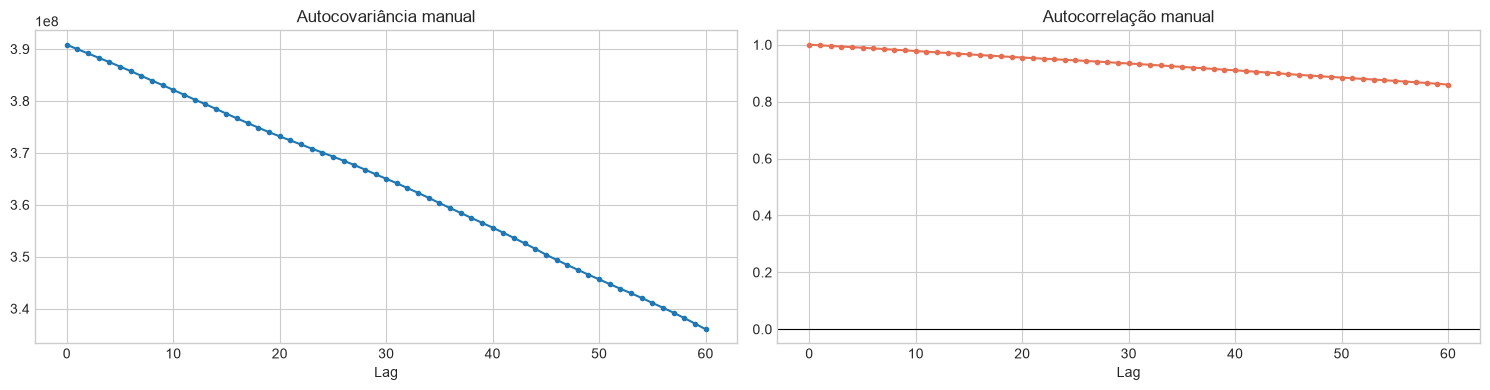

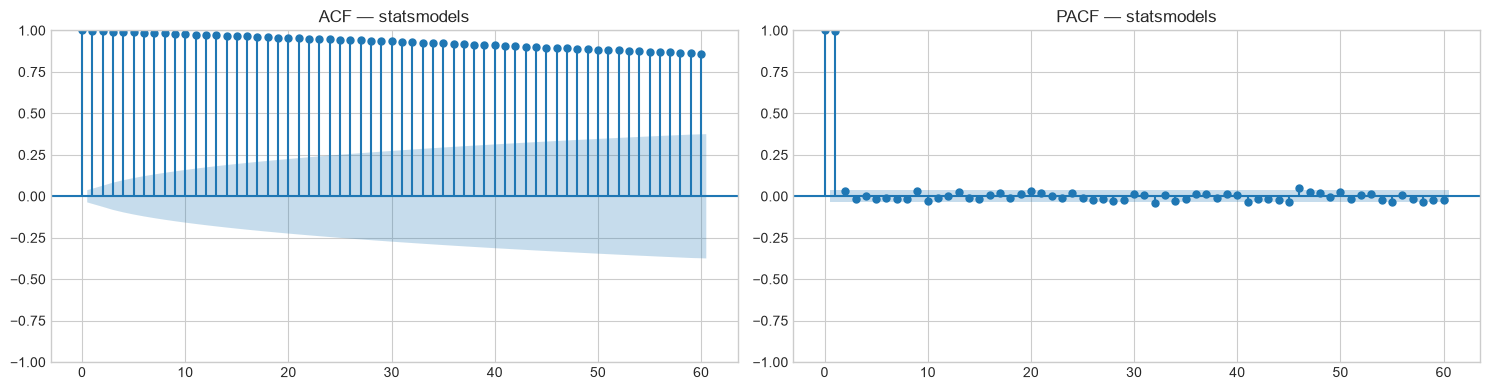

In [3]:
def autocovariance(series, lag):
    values = np.asarray(series, dtype=float)
    n = len(values)
    mean = values.mean()
    if lag < 0 or lag >= n:
        raise ValueError("Lag fora do intervalo da série.")
    return np.sum((values[lag:] - mean) * (values[: n - lag] - mean)) / n

def autocorrelation(series, lag):
    return autocovariance(series, lag) / autocovariance(series, 0)

serie_vendas = df["vendas"]
max_lag = min(60, len(serie_vendas) // 2 - 1)
lags = np.arange(max_lag + 1)
autocov_manual = [autocovariance(serie_vendas, lag) for lag in lags]
autocorr_manual = [autocorrelation(serie_vendas, lag) for lag in lags]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(lags, autocov_manual, marker="o", markersize=3)
axes[0].set_title("Autocovariância manual")
axes[0].set_xlabel("Lag")
axes[1].plot(lags, autocorr_manual, marker="o", markersize=3, color="#e76f51")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Autocorrelação manual")
axes[1].set_xlabel("Lag")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(serie_vendas, lags=max_lag, ax=axes[0], title="ACF — statsmodels")
plot_pacf(serie_vendas, lags=max_lag, ax=axes[1], method="ywm", title="PACF — statsmodels")
plt.tight_layout()
plt.show()


In [4]:
def adf_test(series, alpha=0.05):
    result = adfuller(pd.Series(series).dropna(), autolag="AIC")
    output = {
        "estatistica": result[0], "p_valor": result[1], "lags": result[2],
        "observacoes": result[3], "valores_criticos": result[4],
        "estacionaria": result[1] < alpha,
    }
    print("ADF")
    print(f"  Estatística: {output['estatistica']:.6f}")
    print(f"  p-valor: {output['p_valor']:.6f}")
    print("  Valores críticos:", output["valores_criticos"])
    return output

def kpss_test(series, alpha=0.05):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = kpss(pd.Series(series).dropna(), regression="c", nlags="auto")
    output = {
        "estatistica": result[0], "p_valor": result[1], "lags": result[2],
        "valores_criticos": result[3], "estacionaria": result[1] > alpha,
    }
    print("KPSS")
    print(f"  Estatística: {output['estatistica']:.6f}")
    print(f"  p-valor: {output['p_valor']:.6f}")
    print("  Valores críticos:", output["valores_criticos"])
    return output

resultado_adf = adf_test(serie_vendas, ALPHA)
resultado_kpss = kpss_test(serie_vendas, ALPHA)
estacionaria = resultado_adf["estacionaria"] and resultado_kpss["estacionaria"]
print("SÉRIE ESTACIONÁRIA" if estacionaria else "SÉRIE NÃO ESTACIONÁRIA")


ADF
  Estatística: -1.103160
  p-valor: 0.713810
  Valores críticos: {'1%': np.float64(-3.432682605940669), '5%': np.float64(-2.862570582321741), '10%': np.float64(-2.5673186105021872)}
KPSS
  Estatística: 5.587739
  p-valor: 0.010000
  Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
SÉRIE NÃO ESTACIONÁRIA


C:\Users\matheuscastilho-ieg\AppData\Local\Temp\ipykernel_7240\1317436872.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")


## 3. Separação temporal entre treino e teste

Modo reduzido: 730 linhas de treino e 4 origens finais.
Treino: 2020-06-09 00:00:00 até 2022-06-08 00:00:00 730
Teste : 2022-06-09 00:00:00 até 2022-06-12 00:00:00 4


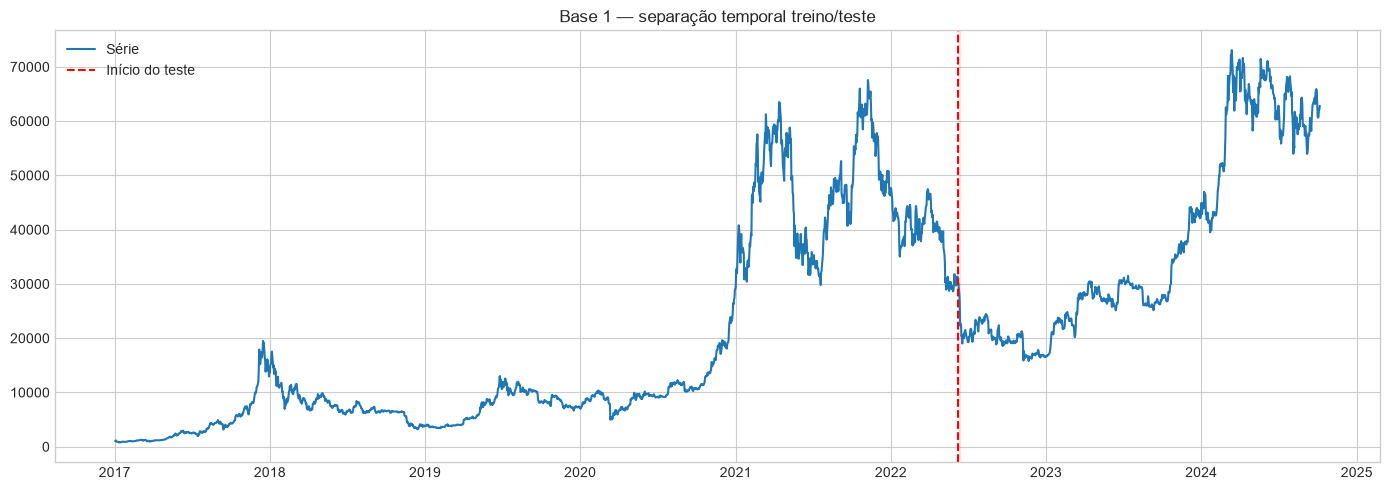

In [5]:
df_train = df.iloc[:-TEST_SIZE].copy()
df_test = df.iloc[-TEST_SIZE:].copy()
if df_train.empty or df_test.empty: raise AssertionError("Treino ou teste vazio.")
if SMOKE_TEST:
    df_train = df_train.iloc[-SMOKE_TRAIN_ROWS:].copy()
    df_test = df_test.iloc[:SMOKE_ORIGINS].copy()
    print(f"Modo reduzido: {len(df_train)} linhas de treino e {len(df_test)} origens finais.")
print("Treino:", df_train.index.min(), "até", df_train.index.max(), len(df_train))
print("Teste :", df_test.index.min(), "até", df_test.index.max(), len(df_test))

plt.figure(figsize=(14, 5)); plt.plot(df.index, df["vendas"], label="Série")
plt.axvline(df_test.index[0], color="red", linestyle="--", label="Início do teste")
plt.axvspan(df_test.index[0], df_test.index[-1], color="red", alpha=0.08)
plt.title(f"Base {BASE_NUMBER} — separação temporal treino/teste"); plt.legend(); plt.tight_layout(); plt.show()

def mape_safe(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true,float), np.asarray(y_pred,float); mask = y_true != 0
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100 if mask.any() else np.nan
def metrics(y_true, y_pred):
    return {"mae":float(mean_absolute_error(y_true,y_pred)),"mape":float(mape_safe(y_true,y_pred))}
def scale_exog(train_exog, other_exog):
    a,b=train_exog.astype(float).copy(),other_exog.astype(float).copy(); scaler=None
    continuous=[c for c in ["temperatura"] if c in a.columns]
    if continuous:
        scaler=StandardScaler(); a.loc[:,continuous]=scaler.fit_transform(a[continuous]); b.loc[:,continuous]=scaler.transform(b[continuous])
    return a,b,scaler
def fit_sarimax_model(y, exog, order, seasonal_order, trend):
    started=time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        y_model = pd.Series(np.asarray(y, dtype=float)).reset_index(drop=True)
        exog_model = None if exog is None else pd.DataFrame(np.asarray(exog, dtype=float)).reset_index(drop=True)
        model=SARIMAX(endog=y_model,exog=exog_model,order=tuple(order),seasonal_order=tuple(seasonal_order),trend=trend,enforce_stationarity=False,enforce_invertibility=False)
        result=model.fit(disp=False,maxiter=MAXITER)
    return result,bool(result.mle_retvals.get("converged",True)),time.perf_counter()-started," | ".join(str(w.message) for w in caught[:3])
def fit_and_forecast(train,future,order,seasonal_order,trend="n",exog_cols=None):
    exog_cols=list(exog_cols or [])
    if exog_cols: x_train,x_future,scaler=scale_exog(train[exog_cols],future[exog_cols])
    else: x_train=x_future=scaler=None
    result,converged,elapsed,warning_text=fit_sarimax_model(train["vendas"],x_train,order,seasonal_order,trend)
    forecast=result.get_forecast(steps=len(future),exog=x_future).predicted_mean; forecast.index=future.index
    return {"result":result,"forecast":forecast,"converged":converged,"elapsed":elapsed,"warning":warning_text,"scaler":scaler}

## 4. Comparação inicial: SARIMA × SARIMAX com exógenas

,modelo,order,seasonal_order,exogenas,BIC,MAE_validacao,MAPE_validacao,convergiu
0,SARIMA_sem_exog,"(0, 1, 0)","(0, 0, 0, 0)",nenhuma,12606.555867,606.825614,1.960511,True
1,SARIMAX_exog_calendario,"(0, 1, 0)","(0, 0, 0, 0)","[temperatura, feriado]",12619.622515,624.086533,2.017243,True
2,SARIMAX_exog_calendario_dezembro,"(0, 1, 0)","(0, 0, 0, 0)","[temperatura, feriado, dezembro]",12625.549842,626.811690,2.026218,True


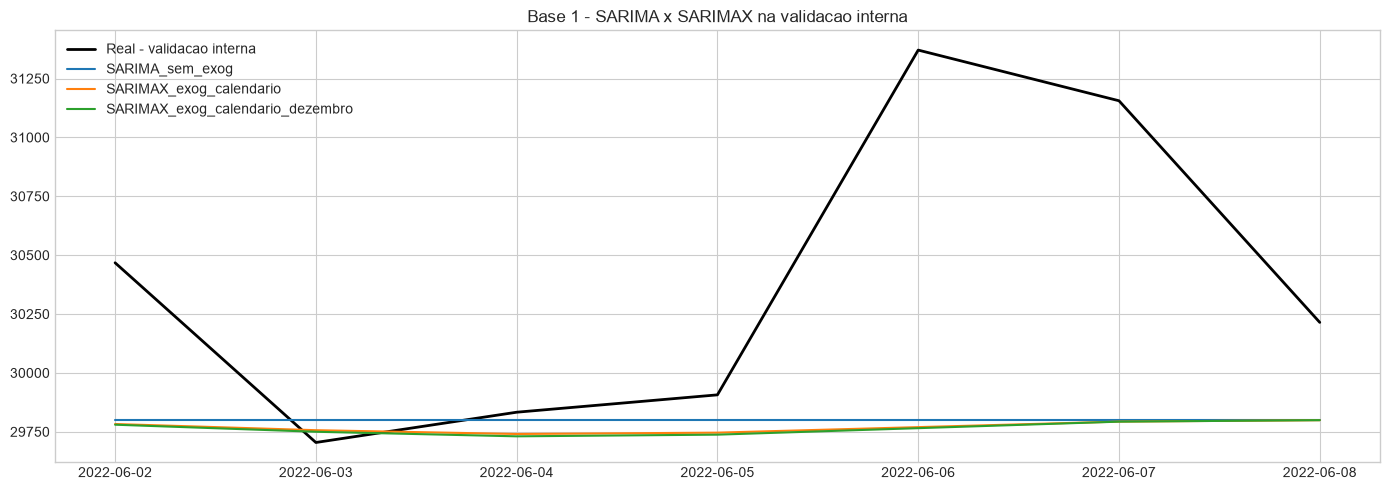

In [6]:
BENCHMARK_ORDER = (0, 1, 0) if SMOKE_TEST else (0, 1, 2)
BENCHMARK_SEASONAL = (0, 0, 0, 0) if SMOKE_TEST else (0, 1, 1, REFERENCE_PERIOD)
benchmark_specs = [
    ("SARIMA_sem_exog", []),
    ("SARIMAX_exog_calendario", ["temperatura", "feriado"]),
    ("SARIMAX_exog_calendario_dezembro", ["temperatura", "feriado", "dezembro"]),
]
benchmark_train = df_train.iloc[:-VALIDATION_HORIZON].copy()
benchmark_validation = df_train.iloc[-VALIDATION_HORIZON:].copy()
assert benchmark_train.index.max() < benchmark_validation.index.min()
benchmark_rows, benchmark_forecasts = [], {}
for model_name, exog_cols in benchmark_specs:
    fitted = fit_and_forecast(
        benchmark_train, benchmark_validation,
        BENCHMARK_ORDER, BENCHMARK_SEASONAL, "n", exog_cols,
    )
    score = metrics(benchmark_validation["vendas"], fitted["forecast"])
    benchmark_rows.append({
        "modelo": model_name, "order": BENCHMARK_ORDER,
        "seasonal_order": BENCHMARK_SEASONAL,
        "exogenas": exog_cols or "nenhuma", "BIC": fitted["result"].bic,
        "MAE_validacao": score["mae"], "MAPE_validacao": score["mape"],
        "convergiu": fitted["converged"],
    })
    benchmark_forecasts[model_name] = fitted["forecast"]
benchmark = pd.DataFrame(benchmark_rows).sort_values(["MAE_validacao", "BIC"])
display(benchmark)
plt.figure(figsize=(14, 5))
plt.plot(benchmark_validation.index, benchmark_validation["vendas"], color="black", lw=2, label="Real - validacao interna")
for name, forecast in benchmark_forecasts.items():
    plt.plot(benchmark_validation.index, forecast, label=name)
plt.title(f"Base {BASE_NUMBER} - SARIMA x SARIMAX na validacao interna")
plt.legend(); plt.tight_layout(); plt.show()


## 5. Busca exaustiva: Base Models, SARIMA e SARIMAX

In [7]:
def validation_folds(n, n_folds=N_FOLDS, horizon=VALIDATION_HORIZON):
    initial = n - n_folds * horizon
    if initial <= 0:
        raise ValueError("Treino insuficiente para os folds solicitados.")
    return [(np.arange(0, initial + fold * horizon), np.arange(initial + fold * horizon, initial + (fold + 1) * horizon)) for fold in range(n_folds)]

FOLDS = validation_folds(len(df_train))
print("Folds temporais:")
for i, (train_idx, val_idx) in enumerate(FOLDS, 1):
    print(i, df_train.index[train_idx[0]].date(), "→", df_train.index[train_idx[-1]].date(), "| validação:", df_train.index[val_idx[0]].date(), "→", df_train.index[val_idx[-1]].date())

def json_default(value):
    if isinstance(value, np.integer): return int(value)
    if isinstance(value, np.floating): return float(value)
    if isinstance(value, np.bool_): return bool(value)
    if isinstance(value, (tuple, set)): return list(value)
    if pd.isna(value): return None
    raise TypeError(f"Tipo não serializável: {type(value)}")

class ResultStore:
    def __init__(self, name):
        self.path = CHECKPOINT_DIR / f"{name}.jsonl"
        self.records, self.seen = [], set()
        if self.path.exists():
            with self.path.open("r", encoding="utf-8") as stream:
                for line in stream:
                    try:
                        record = json.loads(line)
                    except json.JSONDecodeError:
                        continue
                    self.records.append(record)
                    self.seen.add(record["candidate_key"])
            print(f"Retomando {name}: {len(self.records)} candidatos carregados.")
    def add(self, record):
        with self.path.open("a", encoding="utf-8") as stream:
            stream.write(json.dumps(record, ensure_ascii=False, default=json_default) + "\n")
        self.records.append(record)
        self.seen.add(record["candidate_key"])
    def frame(self):
        return pd.DataFrame(self.records)

def candidate_key(payload):
    return json.dumps(payload, sort_keys=True, ensure_ascii=False)

def print_candidate(record, current, total):
    if PRINT_EVERY_CANDIDATE:
        print(
            f"[{current:>7}/{total}] {record['family']:<10} status={record['status']:<15} "
            f"order={record.get('order')} seasonal={record.get('seasonal_order')} "
            f"exog={record.get('exog_key', 'nenhuma')} trend={record.get('trend', '-')} "
            f"MAE_val={record.get('val_mae')} BIC={record.get('bic')} "
            f"tempo={record.get('elapsed_seconds')}s erro={record.get('error', '')}"
        )

def sort_results(frame):
    if frame.empty: return frame
    ordered = frame.copy()
    ordered["_ok"] = ordered["status"].eq("ok")
    ordered["_mae"] = pd.to_numeric(ordered.get("val_mae"), errors="coerce").fillna(np.inf)
    ordered["_bic"] = pd.to_numeric(ordered.get("bic"), errors="coerce").fillna(np.inf)
    return ordered.sort_values(["_ok", "_mae", "_bic"], ascending=[False, True, True]).drop(columns=["_ok", "_mae", "_bic"]).reset_index(drop=True)

def print_full_ranking(frame, title):
    ranking = sort_results(frame)
    if not ranking.empty:
        ranking = ranking.copy()
        ranking.insert(0, "posicao", np.arange(1, len(ranking) + 1))
        ranking.insert(1, "destaque", ["MELHOR MODELO"] + [""] * (len(ranking) - 1))
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 260, "display.max_colwidth", 100):
        print(ranking.to_string(index=False))
    return ranking

def invalid_record(family, payload, error):
    return {
        "candidate_key": candidate_key(payload), "family": family, "status": "invalido",
        "order": payload.get("order"), "seasonal_order": payload.get("seasonal_order"),
        "s": payload.get("s"), "trend": payload.get("trend"),
        "exog_key": payload.get("exog_key", "nenhuma"), "exog_cols": payload.get("exog_cols", []),
        "val_mae": None, "val_mae_std": None, "val_mape": None, "bic": None, "aic": None,
        "converged": False, "elapsed_seconds": 0.0, "warning": "", "error": error,
    }


Folds temporais:
1 2020-06-09 → 2022-05-18 | validação: 2022-05-19 → 2022-05-25
2 2020-06-09 → 2022-05-25 | validação: 2022-05-26 → 2022-06-01
3 2020-06-09 → 2022-06-01 | validação: 2022-06-02 → 2022-06-08


In [8]:
def base_candidates():
    yield {"model": "media_historica", "window": None}
    yield {"model": "mediana_historica", "window": None}
    for lag in [1, 2, 4, 13, 26, 52]: yield {"model": "naive", "lag": lag}
    for window in [4, 8, 13, 26, 52]:
        yield {"model": "media_movel", "window": window}
        yield {"model": "mediana_movel", "window": window}
    for lookback in [None, 13, 26, 52, 104]: yield {"model": "drift", "lookback": lookback}
    for s in S_VALUES: yield {"model": "seasonal_naive", "s": s}

def base_forecast(y_train, horizon, params):
    values, model = np.asarray(y_train, dtype=float), params["model"]
    if model == "media_historica": return np.repeat(values.mean(), horizon)
    if model == "mediana_historica": return np.repeat(np.median(values), horizon)
    if model == "media_movel":
        window = params["window"]
        if len(values) < window: raise ValueError("Histórico insuficiente para a janela.")
        return np.repeat(values[-window:].mean(), horizon)
    if model == "mediana_movel":
        window = params["window"]
        if len(values) < window: raise ValueError("Histórico insuficiente para a janela.")
        return np.repeat(np.median(values[-window:]), horizon)
    if model == "naive":
        lag = params["lag"]
        if len(values) < lag: raise ValueError("Histórico insuficiente para o lag.")
        pattern = values[-lag:]
        return np.array([pattern[i % lag] for i in range(horizon)])
    if model == "seasonal_naive":
        s = params["s"]
        if s == 0: raise ValueError("s=0 representa ausência de sazonalidade.")
        if s == 1: raise ValueError("s=1 não é sazonalidade aplicável.")
        if len(values) < s: raise ValueError("Histórico insuficiente para a sazonalidade.")
        pattern = values[-s:]
        return np.array([pattern[i % s] for i in range(horizon)])
    if model == "drift":
        lookback = params["lookback"]
        selected = values if lookback is None else values[-lookback:]
        if len(selected) < 2: raise ValueError("Histórico insuficiente para drift.")
        slope = (selected[-1] - selected[0]) / (len(selected) - 1)
        return selected[-1] + slope * np.arange(1, horizon + 1)
    raise ValueError(f"Base Model desconhecido: {model}")

def search_base_models():
    candidates, store = list(base_candidates()), ResultStore("base_models")
    total, started_all = len(candidates), time.perf_counter()
    for current, params in enumerate(candidates, 1):
        payload = {"family": "BASE", **params}
        key = candidate_key(payload)
        if key in store.seen: continue
        started = time.perf_counter()
        try:
            fold_mae, fold_mape = [], []
            for train_idx, val_idx in FOLDS:
                pred = base_forecast(df_train["vendas"].iloc[train_idx], len(val_idx), params)
                score = metrics(df_train["vendas"].iloc[val_idx], pred)
                fold_mae.append(score["mae"]); fold_mape.append(score["mape"])
            record = {
                "candidate_key": key, "family": "BASE", "status": "ok", "model": params["model"],
                "params": params, "order": None, "seasonal_order": None, "s": params.get("s"),
                "trend": None, "exog_key": "nenhuma", "exog_cols": [],
                "val_mae": float(np.mean(fold_mae)), "val_mae_std": float(np.std(fold_mae)),
                "val_mape": float(np.mean(fold_mape)), "bic": None, "aic": None,
                "converged": True, "elapsed_seconds": round(time.perf_counter() - started, 4),
                "warning": "", "error": "",
            }
        except Exception as exc:
            record = invalid_record("BASE", payload, str(exc))
            record.update({"model": params["model"], "params": params, "elapsed_seconds": round(time.perf_counter() - started, 4)})
        store.add(record); print_candidate(record, current, total)
    frame = store.frame()
    print(f"Tempo total Base Models: {time.perf_counter() - started_all:.2f}s")
    print_full_ranking(frame, "RANKING COMPLETO — BASE MODELS")
    return frame


In [9]:
def seasonal_combinations():
    for s in S_VALUES:
        if s == 0:
            yield (0, 0, 0, 0)
        else:
            for sp, sd, sq in itertools.product(SP_VALUES, SD_VALUES, SQ_VALUES):
                yield (sp, sd, sq, s)

def statistical_candidate_count(exog_sets_count=1, trend_count=1):
    order_count = len(P_VALUES) * len(D_VALUES) * len(Q_VALUES)
    seasonal_count = sum(1 for _ in seasonal_combinations())
    return order_count * seasonal_count * exog_sets_count * trend_count

def statistical_candidates(family):
    exog_items, trends = ([("nenhuma", [])], ["n"]) if family == "SARIMA" else (list(EXOG_SETS.items()), TREND_VALUES)
    for p, d, q in itertools.product(P_VALUES, D_VALUES, Q_VALUES):
        order = (p, d, q)
        for seasonal_order in seasonal_combinations():
            for exog_key, exog_cols in exog_items:
                for trend in trends:
                    yield {
                        "family": family, "order": order, "seasonal_order": seasonal_order,
                        "s": seasonal_order[3], "exog_key": exog_key,
                        "exog_cols": exog_cols, "trend": trend,
                    }

def evaluate_statistical_candidate(payload):
    family, order = payload["family"], tuple(payload["order"])
    seasonal_order, s = tuple(payload["seasonal_order"]), payload["s"]
    exog_cols, trend = list(payload["exog_cols"]), payload["trend"]
    if s == 1:
        return invalid_record(family, payload, "s=1 auditado, mas não representa periodicidade sazonal válida no statsmodels.")
    started, fold_mae, fold_mape, convergences, warning_messages = time.perf_counter(), [], [], [], []
    try:
        for train_idx, val_idx in FOLDS:
            fold_train, fold_val = df_train.iloc[train_idx], df_train.iloc[val_idx]
            if exog_cols: x_train, x_val, _ = scale_exog(fold_train[exog_cols], fold_val[exog_cols])
            else: x_train = x_val = None
            result, converged, _, warning_text = fit_sarimax_model(fold_train["vendas"], x_train, order, seasonal_order, trend)
            pred = result.get_forecast(steps=len(fold_val), exog=x_val).predicted_mean
            score = metrics(fold_val["vendas"], pred)
            fold_mae.append(score["mae"]); fold_mape.append(score["mape"]); convergences.append(converged)
            if warning_text: warning_messages.append(warning_text)
        if exog_cols:
            x_full_train = df_train[exog_cols].astype(float).copy()
            continuous = [c for c in ["temperatura"] if c in exog_cols]
            if continuous:
                scaler = StandardScaler()
                x_full_train.loc[:, continuous] = scaler.fit_transform(x_full_train[continuous])
        else: x_full_train = None
        full_result, full_converged, _, full_warning = fit_sarimax_model(df_train["vendas"], x_full_train, order, seasonal_order, trend)
        if full_warning: warning_messages.append(full_warning)
        all_converged = bool(all(convergences) and full_converged)
        return {
            "candidate_key": candidate_key(payload), "family": family,
            "status": "ok" if all_converged else "nao_convergiu",
            "order": list(order), "seasonal_order": list(seasonal_order), "s": s,
            "trend": trend, "exog_key": payload["exog_key"], "exog_cols": exog_cols,
            "val_mae": float(np.mean(fold_mae)), "val_mae_std": float(np.std(fold_mae)),
            "val_mape": float(np.mean(fold_mape)), "bic": float(full_result.bic),
            "aic": float(full_result.aic), "converged": all_converged,
            "elapsed_seconds": round(time.perf_counter() - started, 4),
            "warning": " | ".join(warning_messages[:3]), "error": "",
        }
    except Exception as exc:
        record = invalid_record(family, payload, str(exc))
        record["status"] = "erro"
        record["elapsed_seconds"] = round(time.perf_counter() - started, 4)
        return record

def search_statistical_models(family):
    if family == "SARIMA":
        total, store_name = statistical_candidate_count(), "sarima"
    else:
        total, store_name = statistical_candidate_count(len(EXOG_SETS), len(TREND_VALUES)), "sarimax"
    print(f"\n{family}: total esperado de candidatos = {total:,}")
    store, started_all = ResultStore(store_name), time.perf_counter()
    for current, payload in enumerate(statistical_candidates(family), 1):
        if candidate_key(payload) in store.seen: continue
        record = evaluate_statistical_candidate(payload)
        store.add(record); print_candidate(record, current, total)
    frame = store.frame()
    successes, failures = int(frame["status"].eq("ok").sum()), int((~frame["status"].eq("ok")).sum())
    print(f"{family}: esperado={total:,}, registrado={len(frame):,}, sucessos={successes:,}, falhas/inválidos={failures:,}")
    if len(frame) != total: raise AssertionError(f"Busca incompleta de {family}: {len(frame)} de {total}.")
    print(f"Tempo total {family}: {time.perf_counter() - started_all:.2f}s")
    print_full_ranking(frame, f"RANKING COMPLETO — {family}")
    return frame


## 6. Sazonalidades inteiras de s=0 até s=100

In [10]:
print("S_VALUES ativos:", S_VALUES)
print("Contagem SARIMA:", statistical_candidate_count())
print("Contagem SARIMAX:", statistical_candidate_count(len(EXOG_SETS), len(TREND_VALUES)))
if SMOKE_TEST: print("Validação reduzida ativa. Use SMOKE_TEST=False para executar integralmente s=0..100.")

S_VALUES ativos: [0, 1, 4]
Contagem SARIMA: 5
Contagem SARIMAX: 20
Validação reduzida ativa. Use SMOKE_TEST=False para executar integralmente s=0..100.


## 7. Execução candidato a candidato e tabelas completas ordenadas

In [11]:
base_results = search_base_models()
sarima_results = search_statistical_models("SARIMA")
sarimax_results = search_statistical_models("SARIMAX")


Retomando base_models: 26 candidatos carregados.


Tempo total Base Models: 0.00s

RANKING COMPLETO — BASE MODELS
 posicao      destaque                                                    candidate_key family   status             model                                         params order seasonal_order   s trend exog_key exog_cols      val_mae  val_mae_std  val_mape  bic  aic  converged  elapsed_seconds warning                                    error
       1 MELHOR MODELO          {"family": "BASE", "model": "media_movel", "window": 8}   BASE       ok       media_movel          {'model': 'media_movel', 'window': 8}  None           None NaN  None  nenhuma        []   640.894868   233.023436  2.095695 None None       True           0.0137                                                 
       2                        {"family": "BASE", "model": "media_movel", "window": 4}   BASE       ok       media_movel          {'model': 'media_movel', 'window': 4}  None           None NaN  None  nenhuma        []   724.726958   179.574577  2.4005

Retomando sarimax: 20 candidatos carregados.
SARIMAX: esperado=20, registrado=20, sucessos=12, falhas/inválidos=8
Tempo total SARIMAX: 0.00s

RANKING COMPLETO — SARIMAX


 posicao      destaque                                                                                                                                                                                candidate_key  family   status     order seasonal_order  s trend                 exog_key                        exog_cols    val_mae  val_mae_std  val_mape          bic          aic  converged  elapsed_seconds warning                                                                         error
       1 MELHOR MODELO                                  {"exog_cols": ["temperatura"], "exog_key": "exog_principal", "family": "SARIMAX", "order": [0, 1, 0], "s": 0, "seasonal_order": [0, 0, 0, 0], "trend": "n"} SARIMAX       ok [0, 1, 0]   [0, 0, 0, 0]  0     n           exog_principal                    [temperatura] 834.061090   160.863089  2.739084 12730.327166 12721.146564       True           1.5994                                                                                      
       2  

## 8. Vencedores, diagnóstico dos resíduos e rankings

,modelo,configuracao,s,exogenas,BIC,MAE_validacao,DP_MAE_validacao,MAE_teste,MAPE_teste
2,SARIMAX,"{'order': [0, 1, 0], 'seasonal_order': [0, 0, ...",0.0,[temperatura],12730.327166,834.061090,160.863089,1633.921121,5.912827
1,SARIMA,"{'order': [0, 1, 0], 'seasonal_order': [0, 0, ...",0.0,nenhuma,12723.689980,834.202195,161.116222,1634.540039,5.915051
0,Base Model,"{'model': 'media_movel', 'window': 8}",NaN,nenhuma,NaN,640.894868,233.023436,1726.564697,6.237639



TOP 10 BASE MODELS


,candidate_key,family,status,model,params,order,seasonal_order,s,trend,exog_key,exog_cols,val_mae,val_mae_std,val_mape,bic,aic,converged,elapsed_seconds,warning,error
0,"{""family"": ""BASE"", ""model"": ""media_movel"", ""wi...",BASE,ok,media_movel,"{'model': 'media_movel', 'window': 8}",None,None,NaN,None,nenhuma,[],640.894868,233.023436,2.095695,None,None,True,0.0137,,
1,"{""family"": ""BASE"", ""model"": ""media_movel"", ""wi...",BASE,ok,media_movel,"{'model': 'media_movel', 'window': 4}",None,None,NaN,None,nenhuma,[],724.726958,179.574577,2.400532,None,None,True,0.0100,,
2,"{""family"": ""BASE"", ""model"": ""mediana_movel"", ""...",BASE,ok,mediana_movel,"{'model': 'mediana_movel', 'window': 8}",None,None,NaN,None,nenhuma,[],731.175270,259.062830,2.386984,None,None,True,0.0118,,
3,"{""family"": ""BASE"", ""model"": ""mediana_movel"", ""...",BASE,ok,mediana_movel,"{'model': 'mediana_movel', 'window': 4}",None,None,NaN,None,nenhuma,[],741.954288,162.740226,2.458217,None,None,True,0.0173,,
4,"{""family"": ""BASE"", ""lookback"": null, ""model"": ...",BASE,ok,drift,"{'model': 'drift', 'lookback': None}",None,None,NaN,None,nenhuma,[],761.369720,170.868204,2.501267,None,None,True,0.0107,,
5,"{""family"": ""BASE"", ""lag"": 1, ""model"": ""naive""}",BASE,ok,naive,"{'model': 'naive', 'lag': 1}",None,None,NaN,None,nenhuma,[],834.202195,161.116222,2.739539,None,None,True,0.0086,,
6,"{""family"": ""BASE"", ""model"": ""mediana_movel"", ""...",BASE,ok,mediana_movel,"{'model': 'mediana_movel', 'window': 13}",None,None,NaN,None,nenhuma,[],853.669736,142.070108,2.814542,None,None,True,0.0122,,
7,"{""family"": ""BASE"", ""lag"": 2, ""model"": ""naive""}",BASE,ok,naive,"{'model': 'naive', 'lag': 2}",None,None,NaN,None,nenhuma,[],946.752418,32.302238,3.131184,None,None,True,0.0109,,
8,"{""family"": ""BASE"", ""model"": ""media_movel"", ""wi...",BASE,ok,media_movel,"{'model': 'media_movel', 'window': 13}",None,None,NaN,None,nenhuma,[],1034.470531,338.454129,3.437572,None,None,True,0.0133,,
9,"{""family"": ""BASE"", ""lag"": 4, ""model"": ""naive""}",BASE,ok,naive,"{'model': 'naive', 'lag': 4}",None,None,NaN,None,nenhuma,[],1115.983259,146.303821,3.696344,None,None,True,0.0106,,



TOP 10 SARIMA


,candidate_key,family,status,order,seasonal_order,s,trend,exog_key,exog_cols,val_mae,val_mae_std,val_mape,bic,aic,converged,elapsed_seconds,warning,error
0,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,nenhuma,[],834.202195,161.116222,2.739539,12723.689980,12719.099679,True,0.1723,,
1,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,nenhuma,[],834.202195,161.116222,2.739539,12723.689980,12719.099679,True,0.2631,,
2,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,nenhuma,[],842.237378,168.974014,2.767907,12679.553159,12670.380816,True,0.3105,,
3,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,invalido,"[0, 1, 0]","[0, 0, 0, 1]",1,n,nenhuma,[],NaN,NaN,NaN,NaN,NaN,False,0.0000,,"s=1 auditado, mas não representa periodicidade..."
4,"{""exog_cols"": [], ""exog_key"": ""nenhuma"", ""fami...",SARIMA,invalido,"[0, 1, 0]","[1, 0, 0, 1]",1,n,nenhuma,[],NaN,NaN,NaN,NaN,NaN,False,0.0000,,"s=1 auditado, mas não representa periodicidade..."



TOP 10 SARIMAX


,candidate_key,family,status,order,seasonal_order,s,trend,exog_key,exog_cols,val_mae,val_mae_std,val_mape,bic,aic,converged,elapsed_seconds,warning,error
0,"{""exog_cols"": [""temperatura""], ""exog_key"": ""ex...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,exog_principal,[temperatura],834.061090,160.863089,2.739084,12730.327166,12721.146564,True,1.5994,,
1,"{""exog_cols"": [""temperatura""], ""exog_key"": ""ex...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,exog_principal,[temperatura],834.061090,160.863089,2.739084,12730.327166,12721.146564,True,1.8851,,
2,"{""exog_cols"": [""temperatura""], ""exog_key"": ""ex...",SARIMAX,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,exog_principal,[temperatura],842.076559,168.783229,2.767389,12686.140358,12672.381843,True,0.4588,,
3,"{""exog_cols"": [""temperatura"", ""feriado""], ""exo...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,exog_calendario,"[temperatura, feriado]",842.752747,154.712371,2.767201,12736.778667,12723.007764,True,2.2137,,
4,"{""exog_cols"": [""temperatura"", ""feriado""], ""exo...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,exog_calendario,"[temperatura, feriado]",842.752747,154.712371,2.767201,12736.778667,12723.007764,True,1.9586,,
5,"{""exog_cols"": [""feriado""], ""exog_key"": ""calend...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,calendario,[feriado],842.958237,154.906649,2.767875,12730.188473,12721.007871,True,1.5947,,
6,"{""exog_cols"": [""feriado""], ""exog_key"": ""calend...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,calendario,[feriado],842.958237,154.906649,2.767875,12730.188473,12721.007871,True,1.4004,,
7,"{""exog_cols"": [""temperatura"", ""feriado"", ""deze...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 0]",0,n,exog_calendario_dezembro,"[temperatura, feriado, dezembro]",844.316655,154.049093,2.772230,12742.698693,12724.337488,True,2.8917,,
8,"{""exog_cols"": [""temperatura"", ""feriado"", ""deze...",SARIMAX,ok,"[0, 1, 0]","[0, 0, 0, 4]",4,n,exog_calendario_dezembro,"[temperatura, feriado, dezembro]",844.316655,154.049093,2.772230,12742.698693,12724.337488,True,2.6729,,
9,"{""exog_cols"": [""temperatura"", ""feriado""], ""exo...",SARIMAX,ok,"[0, 1, 0]","[1, 0, 0, 4]",4,n,exog_calendario,"[temperatura, feriado]",846.128417,171.332553,2.779878,12692.586370,12674.241684,True,0.4978,,


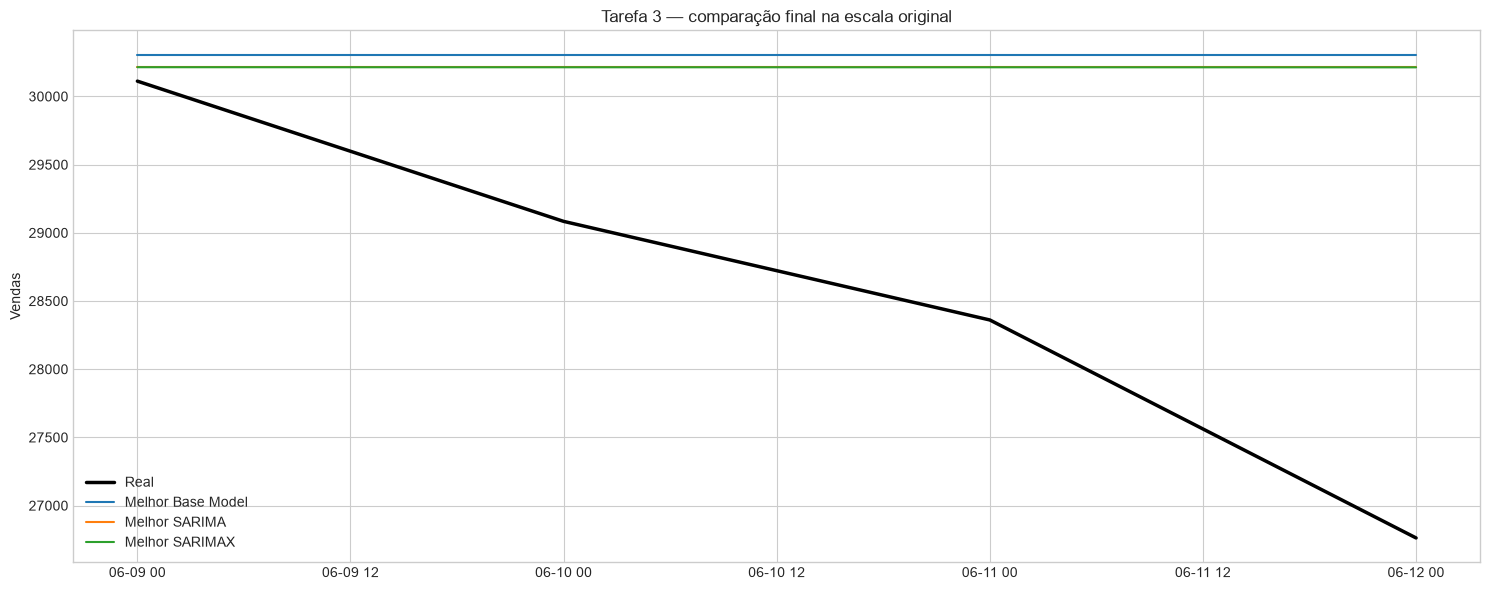

In [12]:
def best_valid_row(frame, filters=None):
    selected = frame.copy()
    if filters:
        for col, value in filters.items(): selected = selected[selected[col] == value]
    accepted_status = ['ok', 'nao_convergiu'] if SMOKE_TEST else ['ok']
    selected = sort_results(selected[selected['status'].isin(accepted_status)])
    if selected.empty: raise RuntimeError(f"Nenhum candidato válido para filtros={filters}")
    return selected.iloc[0]

def evaluate_base_on_test(best_row):
    pred = base_forecast(df_train["vendas"], len(df_test), best_row["params"])
    return pd.Series(pred, index=df_test.index), metrics(df_test["vendas"], pred)

def evaluate_statistical_on_test(best_row):
    fitted = fit_and_forecast(
        df_train, df_test, tuple(best_row["order"]), tuple(best_row["seasonal_order"]),
        best_row["trend"], list(best_row["exog_cols"])
    )
    return fitted, metrics(df_test["vendas"], fitted["forecast"])

best_base, best_sarima, best_sarimax = best_valid_row(base_results), best_valid_row(sarima_results), best_valid_row(sarimax_results)
base_forecast_test, base_score = evaluate_base_on_test(best_base)
sarima_final, sarima_score = evaluate_statistical_on_test(best_sarima)
sarimax_final, sarimax_score = evaluate_statistical_on_test(best_sarimax)

comparison_final = pd.DataFrame([
    {"modelo": "Base Model", "configuracao": best_base["params"], "s": best_base.get("s"), "exogenas": "nenhuma", "BIC": np.nan, "MAE_validacao": best_base["val_mae"], "DP_MAE_validacao": best_base["val_mae_std"], "MAE_teste": base_score["mae"], "MAPE_teste": base_score["mape"]},
    {"modelo": "SARIMA", "configuracao": {"order": best_sarima["order"], "seasonal_order": best_sarima["seasonal_order"], "trend": best_sarima["trend"]}, "s": best_sarima["s"], "exogenas": "nenhuma", "BIC": best_sarima["bic"], "MAE_validacao": best_sarima["val_mae"], "DP_MAE_validacao": best_sarima["val_mae_std"], "MAE_teste": sarima_score["mae"], "MAPE_teste": sarima_score["mape"]},
    {"modelo": "SARIMAX", "configuracao": {"order": best_sarimax["order"], "seasonal_order": best_sarimax["seasonal_order"], "trend": best_sarimax["trend"]}, "s": best_sarimax["s"], "exogenas": best_sarimax["exog_cols"], "BIC": best_sarimax["bic"], "MAE_validacao": best_sarimax["val_mae"], "DP_MAE_validacao": best_sarimax["val_mae_std"], "MAE_teste": sarimax_score["mae"], "MAPE_teste": sarimax_score["mape"]},
]).sort_values("MAE_teste")
display(comparison_final)

print("\nTOP 10 BASE MODELS"); display(sort_results(base_results).head(10))
print("\nTOP 10 SARIMA"); display(sort_results(sarima_results).head(10))
print("\nTOP 10 SARIMAX"); display(sort_results(sarimax_results).head(10))

plt.figure(figsize=(15, 6))
plt.plot(df_test.index, df_test["vendas"], color="black", linewidth=2.5, label="Real")
plt.plot(df_test.index, base_forecast_test, label="Melhor Base Model")
plt.plot(df_test.index, sarima_final["forecast"], label="Melhor SARIMA")
plt.plot(df_test.index, sarimax_final["forecast"], label="Melhor SARIMAX")
plt.title("Tarefa 3 — comparação final na escala original")
plt.ylabel("Vendas")
plt.legend()
plt.tight_layout()
plt.show()



SAZONALIDADES — SARIMA
 posicao  s  melhor_mae  mae_mediano   melhor_bic  modelos_validos  tempo_total
       1  4  834.202195   838.219787 12679.553159                2       0.5736
       2  0  834.202195   834.202195 12723.689980                1       0.1723


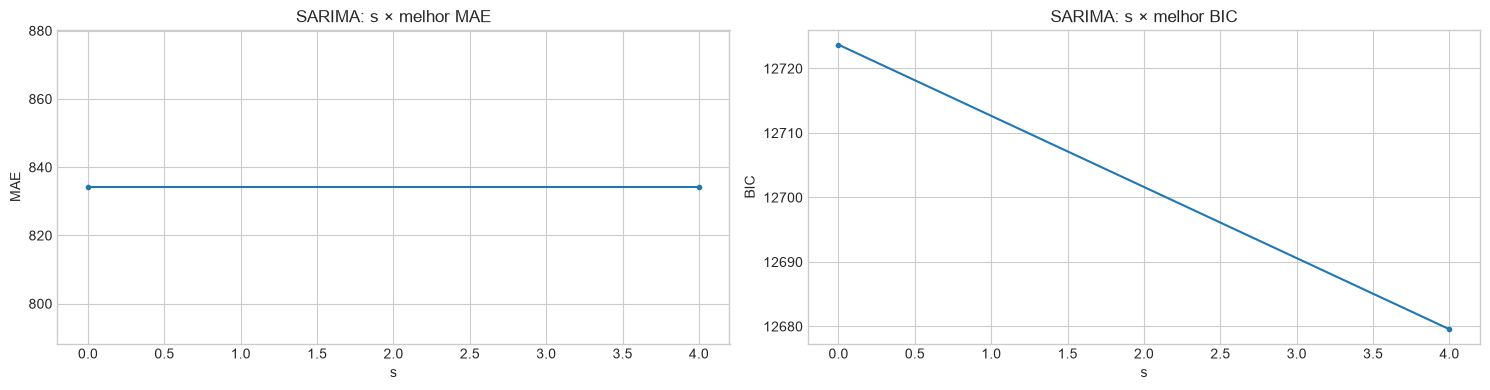


SAZONALIDADES — SARIMAX
 posicao  s  melhor_mae  mae_mediano   melhor_bic  modelos_validos  tempo_total
       1  4   834.06109   843.637446 12685.999465                8       9.8650
       2  0   834.06109   842.855492 12730.188473                4       8.2995


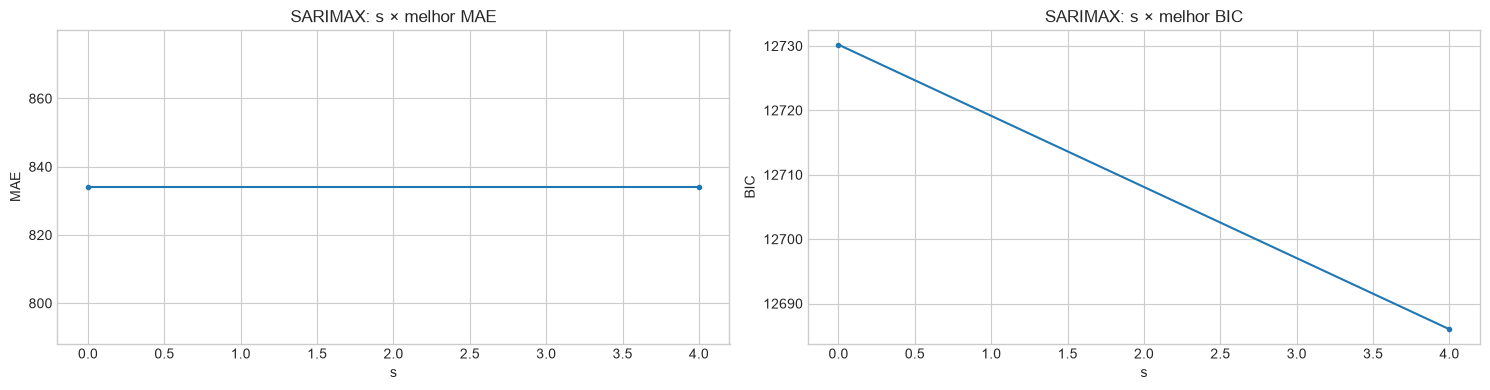

In [13]:
def seasonality_ranking(frame, family_name):
    valid = frame[frame["status"] == "ok"].copy()
    if valid.empty: return pd.DataFrame()
    summary = valid.groupby("s", dropna=False).agg(
        melhor_mae=("val_mae", "min"), mae_mediano=("val_mae", "median"),
        melhor_bic=("bic", "min"), modelos_validos=("candidate_key", "count"),
        tempo_total=("elapsed_seconds", "sum"),
    ).reset_index().sort_values(["melhor_mae", "melhor_bic"])
    summary.insert(0, "posicao", np.arange(1, len(summary) + 1))
    print(f"\nSAZONALIDADES — {family_name}")
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        print(summary.to_string(index=False))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(summary["s"], summary["melhor_mae"], marker="o", markersize=3)
    axes[0].set_title(f"{family_name}: s × melhor MAE"); axes[0].set_xlabel("s"); axes[0].set_ylabel("MAE")
    axes[1].plot(summary["s"], summary["melhor_bic"], marker="o", markersize=3)
    axes[1].set_title(f"{family_name}: s × melhor BIC"); axes[1].set_xlabel("s"); axes[1].set_ylabel("BIC")
    plt.tight_layout(); plt.show()
    return summary

sarima_seasonality = seasonality_ranking(sarima_results, "SARIMA")
sarimax_seasonality = seasonality_ranking(sarimax_results, "SARIMAX")


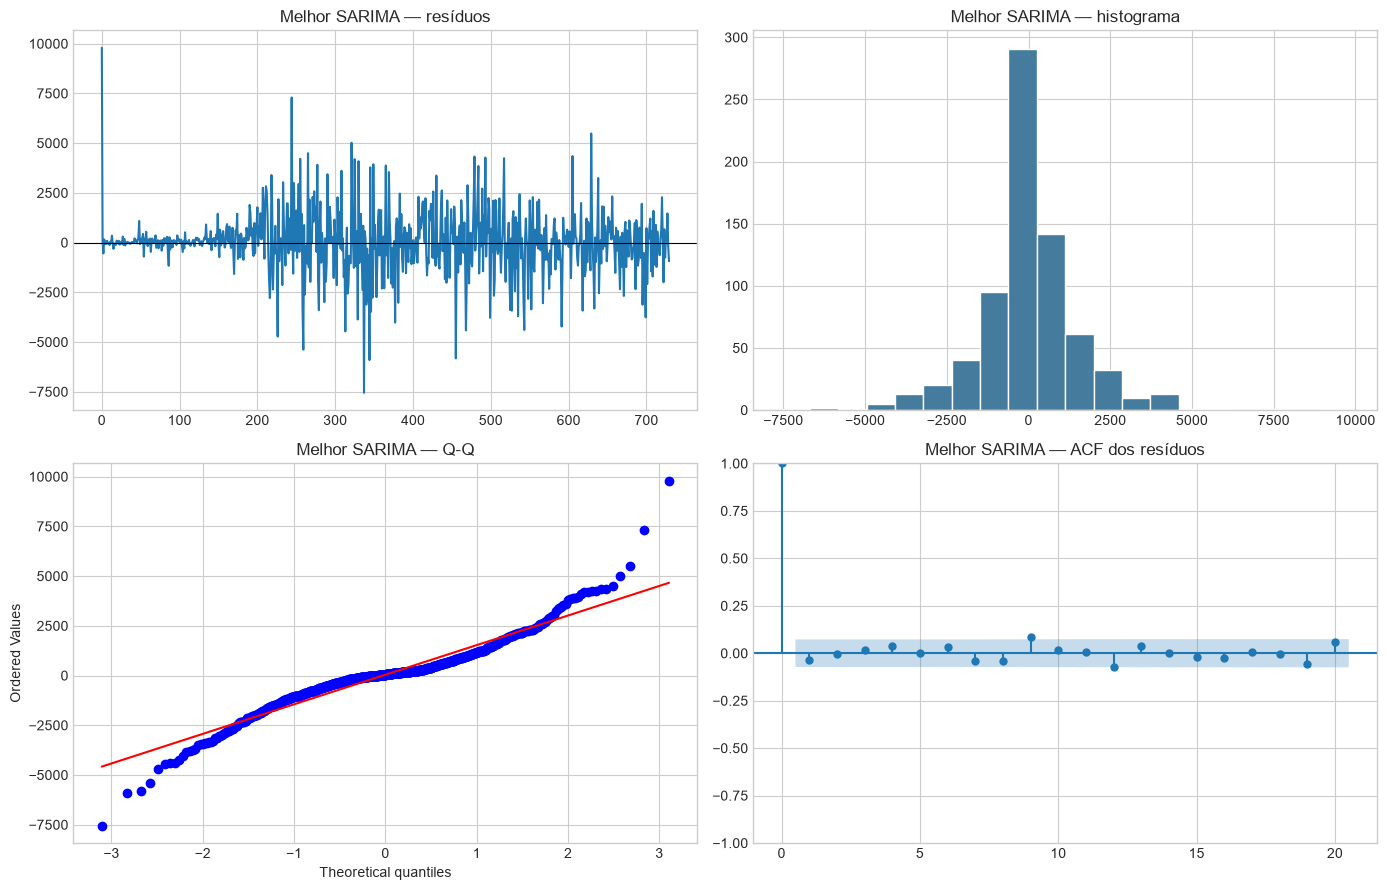

,lb_stat,lb_pvalue
20,22.2032,0.329587


Resíduos compatíveis com ruído branco.


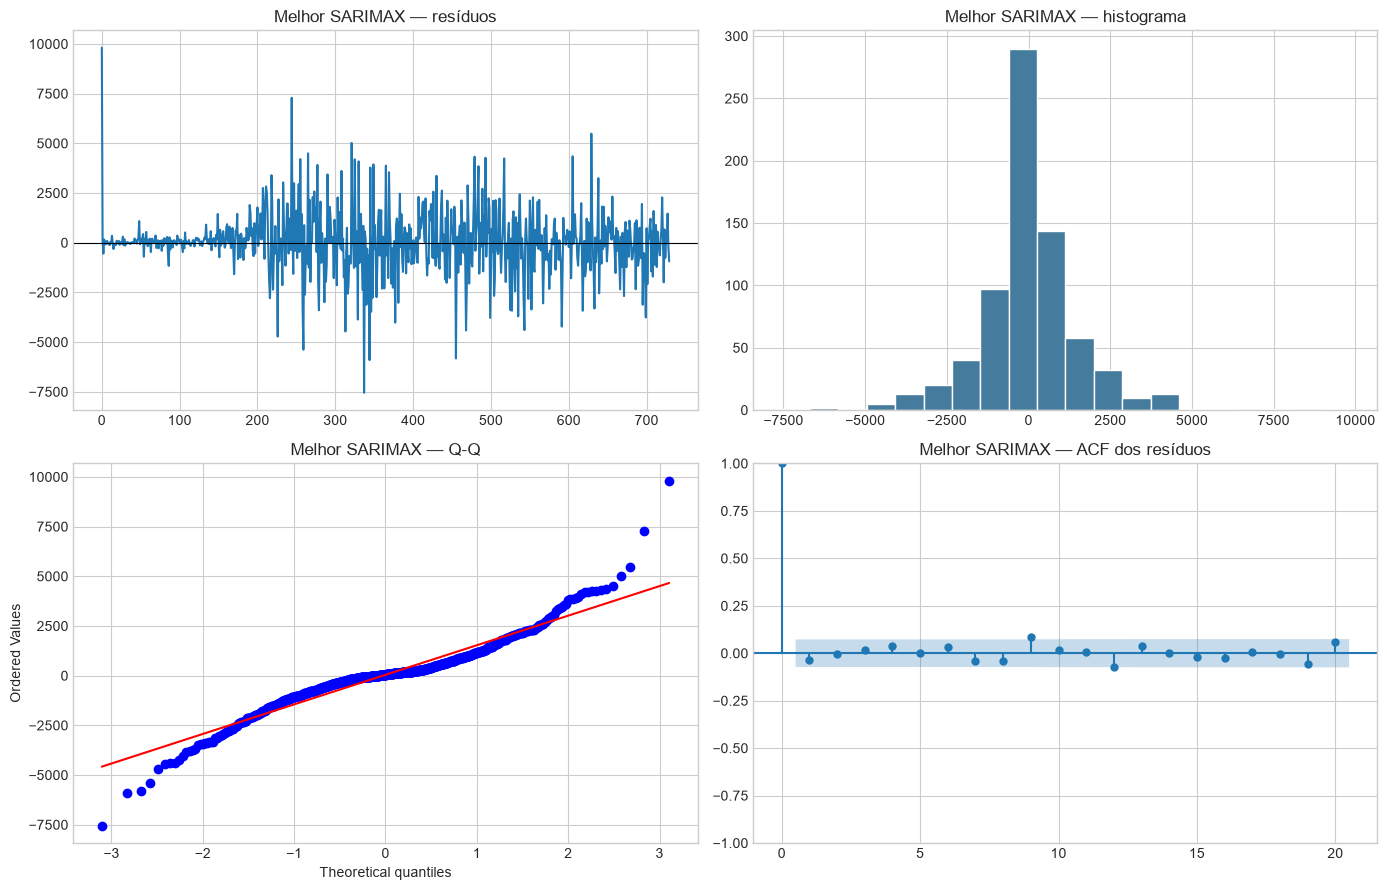

,lb_stat,lb_pvalue
20,22.205442,0.329468


Resíduos compatíveis com ruído branco.


In [14]:
def residual_diagnostics(result, model_name, alpha=0.05):
    residuals = pd.Series(result.resid).dropna()
    lag = min(20, max(1, len(residuals) // 5))
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(residuals); axes[0, 0].axhline(0, color="black", linewidth=0.8); axes[0, 0].set_title(f"{model_name} — resíduos")
    axes[0, 1].hist(residuals, bins=20, color="#457b9d", edgecolor="white"); axes[0, 1].set_title(f"{model_name} — histograma")
    stats.probplot(residuals, dist="norm", plot=axes[1, 0]); axes[1, 0].set_title(f"{model_name} — Q-Q")
    plot_acf(residuals, lags=lag, ax=axes[1, 1], title=f"{model_name} — ACF dos resíduos")
    plt.tight_layout(); plt.show()
    lb = acorr_ljungbox(residuals, lags=[lag], return_df=True)
    display(lb)
    pvalue = float(lb["lb_pvalue"].iloc[0])
    print("Resíduos compatíveis com ruído branco." if pvalue > alpha else "Há autocorrelação significativa remanescente.")
    return {"media_residuos": float(residuals.mean()), "desvio_residuos": float(residuals.std()), "ljung_box_lag": lag, "ljung_box_p": pvalue}

diag_sarima = residual_diagnostics(sarima_final["result"], "Melhor SARIMA")
diag_sarimax = residual_diagnostics(sarimax_final["result"], "Melhor SARIMAX")


In [15]:
# TESTE FINAL CORRIGIDO - walk-forward de um passo, com reestimativa por origem
# Os hiperparametros vencedores permanecem congelados; somente o ajuste e refeito.
import sys
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
from series_temporais.validation import validate_prediction_frame

# "temperatura" representa a exogena primaria ja defasada em um passo.
# Calendario e indicador de dezembro sao conhecidos antes da data-alvo.
KNOWN_AT_ORIGIN_EXOG = {"temperatura", "feriado", "dezembro"}

def walk_forward_base_model(params):
    history = list(df_train["vendas"].astype(float))
    rows = []
    cutoff = df_train.index[-1]
    for target_time, row in df_test.iterrows():
        prediction = float(base_forecast(np.asarray(history), 1, params)[0])
        rows.append({"origin_time": cutoff, "target_time": target_time, "y_true": float(row["vendas"]), "y_pred": prediction, "training_target_cutoff": cutoff})
        history.append(float(row["vendas"]))
        cutoff = target_time
    frame = pd.DataFrame(rows)
    validate_prediction_frame(frame)
    return frame

def walk_forward_sarimax_model(best_row):
    requested = list(best_row["exog_cols"])
    exog_cols = [column for column in requested if column in KNOWN_AT_ORIGIN_EXOG]
    excluded = sorted(set(requested).difference(exog_cols))
    if excluded:
        print("Exogenas removidas por nao serem conhecidas na origem:", excluded)
    history = df_train.copy()
    rows, convergence, warnings_seen = [], [], []
    for target_time, row in df_test.iterrows():
        cutoff = history.index[-1]
        if exog_cols:
            x_history, x_future, _ = scale_exog(
                history[exog_cols], row[exog_cols].to_frame().T,
            )
        else:
            x_history = x_future = None
        result, converged, _, warning_text = fit_sarimax_model(
            history["vendas"].astype(float), x_history,
            tuple(best_row["order"]), tuple(best_row["seasonal_order"]), best_row["trend"],
        )
        prediction = float(result.get_forecast(steps=1, exog=x_future).predicted_mean.iloc[0])
        rows.append({"origin_time": cutoff, "target_time": target_time, "y_true": float(row["vendas"]), "y_pred": prediction, "training_target_cutoff": cutoff})
        convergence.append(converged)
        if warning_text:
            warnings_seen.append(warning_text)
        history = pd.concat([history, row.to_frame().T.set_axis([target_time])])
    frame = pd.DataFrame(rows)
    validate_prediction_frame(frame)
    return frame, all(convergence), " | ".join(warnings_seen[:3]), exog_cols

base_predictions = walk_forward_base_model(best_base["params"])
sarima_predictions, sarima_converged, sarima_warning, _ = walk_forward_sarimax_model(best_sarima)
sarimax_predictions, sarimax_converged, sarimax_warning, sarimax_exog = walk_forward_sarimax_model(best_sarimax)
base_forecast_test = pd.Series(base_predictions.y_pred.to_numpy(), index=df_test.index)
sarima_final = {"forecast": pd.Series(sarima_predictions.y_pred.to_numpy(), index=df_test.index)}
sarimax_final = {"forecast": pd.Series(sarimax_predictions.y_pred.to_numpy(), index=df_test.index)}
base_score = metrics(base_predictions.y_true, base_predictions.y_pred)
sarima_score = metrics(sarima_predictions.y_true, sarima_predictions.y_pred)
sarimax_score = metrics(sarimax_predictions.y_true, sarimax_predictions.y_pred)
comparison_final = pd.DataFrame([
    {"modelo": "Base Model", "MAE_teste": base_score["mae"], "MAPE_teste": base_score["mape"], "origens": len(base_predictions), "horizonte": "1 passo"},
    {"modelo": "SARIMA", "MAE_teste": sarima_score["mae"], "MAPE_teste": sarima_score["mape"], "origens": len(sarima_predictions), "horizonte": "1 passo"},
    {"modelo": "SARIMAX", "MAE_teste": sarimax_score["mae"], "MAPE_teste": sarimax_score["mape"], "origens": len(sarimax_predictions), "horizonte": "1 passo", "exogenas": sarimax_exog},
]).sort_values("MAE_teste")
display(comparison_final)


,modelo,MAE_teste,MAPE_teste,origens,horizonte,exogenas
2,SARIMAX,862.469946,3.097366,4,1 passo,[temperatura]
1,SARIMA,862.926758,3.099022,4,1 passo,NaN
0,Base Model,1627.433655,5.871361,4,1 passo,NaN
